In [93]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
import numpy as np
from sklearn.feature_selection import VarianceThreshold


# Data Import and Cleaning

In [94]:
listings = pd.read_csv("..\\Data\\Airbnb_NY_City_04112024\\listings.csv")
booking_ratios = pd.read_csv("listing_booking_info.csv")
neighborhood_facilities = pd.read_csv("factype_count_per_airbnb_neighborhood.csv")
amenities = pd.read_csv("All_amenities_presence_absence.csv")


filter amenities that are in very few listings to reduce noise

In [95]:
amenities.index = amenities['id']
threshold_lower = len(amenities) * 0.1
threshold_upper = len(amenities) * 0.75
amenity_counts = amenities.sum()
amenities_to_keep = amenity_counts[(amenity_counts >= threshold_lower) & (amenity_counts <= threshold_upper)].index
amenities_filtered = amenities[amenities_to_keep]

amenities_filtered.head()

,bathtub,laundromat nearby,clothing storage,elevator,window ac unit,air conditioning,hangers,coffee maker,bed linens,refrigerator,hot water kettle,private entrance,wine glasses,conditioner,iron,freezer,hot water,free street parking,coffee,dedicated workspace,dishes and silverware,room-darkening shades,host greets you,long term stays allowed,central heating,microwave,lockbox,free parking on premises,hair dryer,first aid kit,luggage dropoff allowed,dryer,books and reading material,dining table,extra pillows and blankets,washer,dishwasher,stove,cleaning products,blender,heating,fire extinguisher,shower gel,cooking basics,oven,baking sheet,self check-in,pets allowed,shampoo,lock on bedroom door,tv with standard cable,tv,toaster,body soap,exterior security cameras on property
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2595,1,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,1,1,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,1,0,1,1,1,1,0,0,0,0,1,0,0,0
6848,0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,1,1,0,0,1,1,0,1,1,0,0,0,1,0,0,1,0,0,0
6872,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1
6990,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0
7064,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0


## Cluster amenities only

In [96]:
amenities_for_clustering = amenities_filtered.copy()
#amenities_for_clustering.index = amenities_filtered['id']
amenities_for_clustering.head()

,bathtub,laundromat nearby,clothing storage,elevator,window ac unit,air conditioning,hangers,coffee maker,bed linens,refrigerator,hot water kettle,private entrance,wine glasses,conditioner,iron,freezer,hot water,free street parking,coffee,dedicated workspace,dishes and silverware,room-darkening shades,host greets you,long term stays allowed,central heating,microwave,lockbox,free parking on premises,hair dryer,first aid kit,luggage dropoff allowed,dryer,books and reading material,dining table,extra pillows and blankets,washer,dishwasher,stove,cleaning products,blender,heating,fire extinguisher,shower gel,cooking basics,oven,baking sheet,self check-in,pets allowed,shampoo,lock on bedroom door,tv with standard cable,tv,toaster,body soap,exterior security cameras on property
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2595,1,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,1,1,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,1,0,1,1,1,1,0,0,0,0,1,0,0,0
6848,0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,1,1,0,0,1,1,0,1,1,0,0,0,1,0,0,1,0,0,0
6872,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1
6990,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0
7064,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [97]:
# removoe listings with too high booking ratio
to_keep = booking_ratios[(booking_ratios['booking_ratio'] <= 0.70)]
filtered_amenities_for_clustering = amenities_for_clustering[amenities_for_clustering.index.isin(to_keep['listing_id'])]
filtered_amenities_for_clustering.head()

#filtered_amenities_for_clustering = filtered_amenities_for_clustering.drop(columns=['Unnamed: 2'])
filtered_amenities_for_clustering

,bathtub,laundromat nearby,clothing storage,elevator,window ac unit,air conditioning,hangers,coffee maker,bed linens,refrigerator,hot water kettle,private entrance,wine glasses,conditioner,iron,freezer,hot water,free street parking,coffee,dedicated workspace,dishes and silverware,room-darkening shades,host greets you,long term stays allowed,central heating,microwave,lockbox,free parking on premises,hair dryer,first aid kit,luggage dropoff allowed,dryer,books and reading material,dining table,extra pillows and blankets,washer,dishwasher,stove,cleaning products,blender,heating,fire extinguisher,shower gel,cooking basics,oven,baking sheet,self check-in,pets allowed,shampoo,lock on bedroom door,tv with standard cable,tv,toaster,body soap,exterior security cameras on property
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2595,1,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,1,1,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,1,0,1,1,1,1,0,0,0,0,1,0,0,0
6848,0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,1,1,0,0,1,1,0,1,1,0,0,0,1,0,0,1,0,0,0
6990,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0
7097,0,0,0,0,0,0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0,0,1,0,1,1,0,1,1,1,0,1,0,1,0,0,0,1,0,1,1,1,1,0,0,1,0,1,0,0,0,1,0,0
7801,1,0,0,0,1,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,1,0,1,0,0,1,1,0,0,1,1,1,0,1,0,1,1,1,1,1,1,0,1,0,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280784833142464571,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1281096465598617765,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1281263542832791722,1,0,0,0,0,1,1,0,1,1,0,0,0,0,1,1,0,1,0,1,1,0,0,1,0,1,0,0,0,1,0,0,0,1,1,1,1,0,1,1,1,1,0,1,1,1,0,0,0,0,0,1,1,0,0


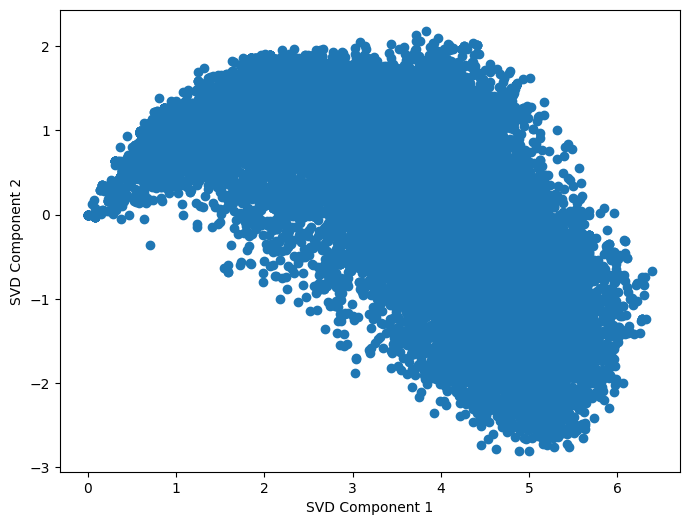

In [6]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Use TruncatedSVD as a replacement for PCA
svd = TruncatedSVD(n_components=2)
svd_components = svd.fit_transform(filtered_amenities_for_clustering)

plt.figure(figsize=(8, 6))
plt.scatter(svd_components[:, 0], svd_components[:, 1])
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.show()

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


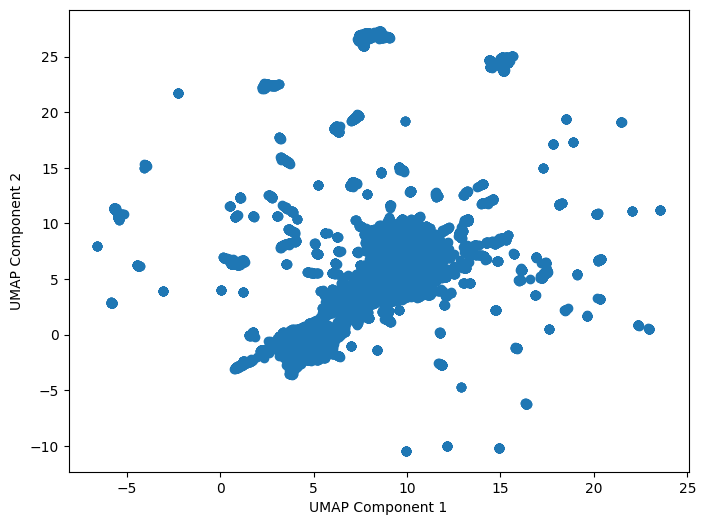

In [69]:
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_components = umap_model.fit_transform(filtered_amenities_for_clustering)

plt.figure(figsize=(8, 6))
plt.scatter(umap_components[:, 0], umap_components[:, 1]) 
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()

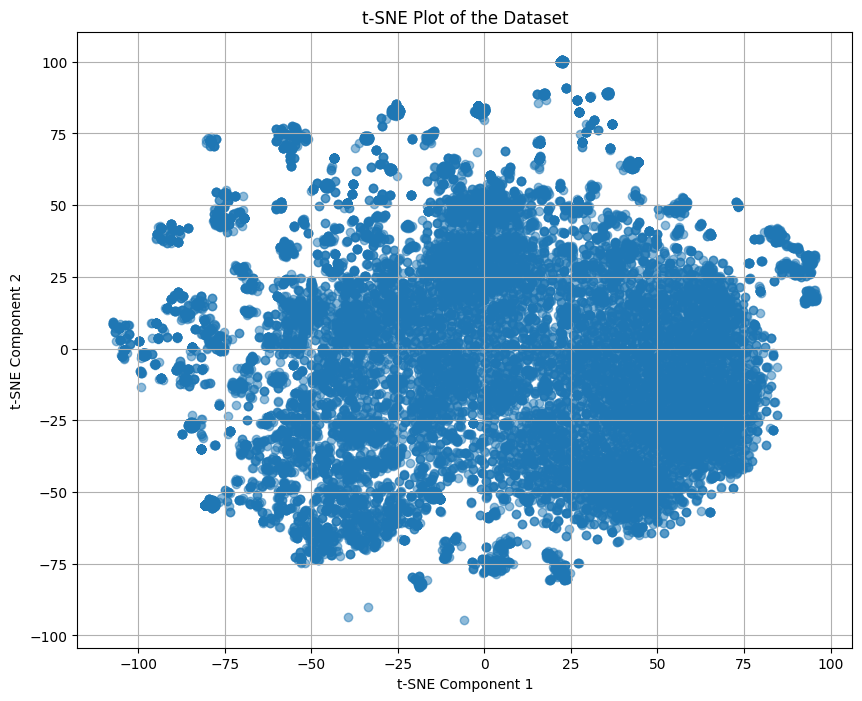

In [8]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_components = tsne.fit_transform(filtered_amenities_for_clustering)
plt.figure(figsize=(10, 8))
plt.scatter(tsne_components[:, 0], tsne_components[:, 1], alpha=0.5)

plt.title("t-SNE Plot of the Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()

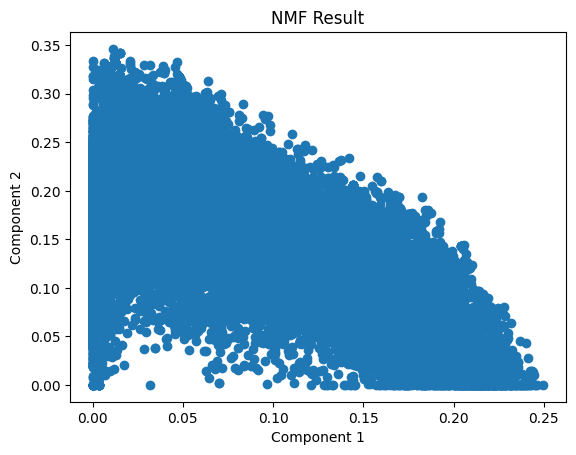

In [9]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=2, random_state=42)
nmf_result = nmf.fit_transform(filtered_amenities_for_clustering)

plt.scatter(nmf_result[:, 0], nmf_result[:, 1])
plt.title("NMF Result")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


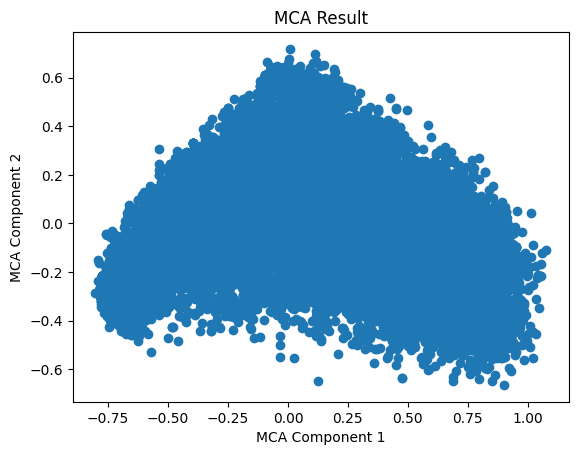

In [10]:
import prince

mca = prince.MCA(n_components=2)
mca_result = mca.fit_transform(filtered_amenities_for_clustering)

plt.scatter(mca_result.iloc[:, 0], mca_result.iloc[:, 1])
plt.title("MCA Result")
plt.xlabel("MCA Component 1")
plt.ylabel("MCA Component 2")
plt.show()

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6796 - val_loss: 0.6306
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6154 - val_loss: 0.5774
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5665 - val_loss: 0.5368
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5280 - val_loss: 0.5042
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4974 - val_loss: 0.4827
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4791 - val_loss: 0.4702
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4682 - val_loss: 0.4622
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4617 - val_loss: 0.4567
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4560 - val_loss: 0.4525
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4521 - val_loss: 0.4492
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4489 - val_loss: 0.4463
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4451 - val_lo

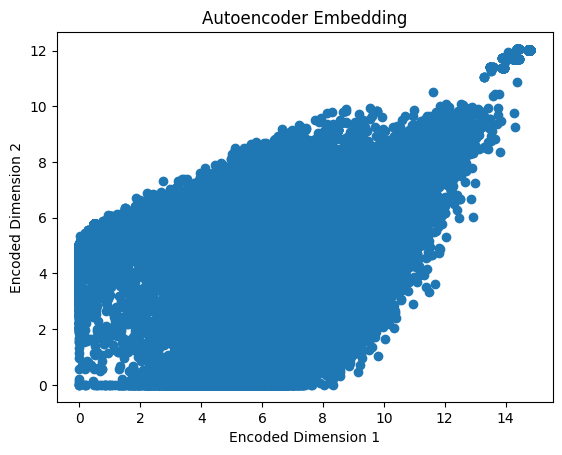

In [11]:
from keras.layers import Input, Dense
from keras.models import Model

input_dim = filtered_amenities_for_clustering.shape[1]  # Number of features
encoding_dim = 2  # Number of dimensions for encoding

# Define the autoencoder model
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Fit the model
autoencoder.fit(filtered_amenities_for_clustering, filtered_amenities_for_clustering, epochs=50, batch_size=256, shuffle=True, validation_data=(filtered_amenities_for_clustering, filtered_amenities_for_clustering))

# Get the lower-dimensional representation
encoded_data = encoder.predict(filtered_amenities_for_clustering)

# Plot the result
plt.scatter(encoded_data[:, 0], encoded_data[:, 1])
plt.title("Autoencoder Embedding")
plt.xlabel("Encoded Dimension 1")
plt.ylabel("Encoded Dimension 2")
plt.show()

## Tune umap

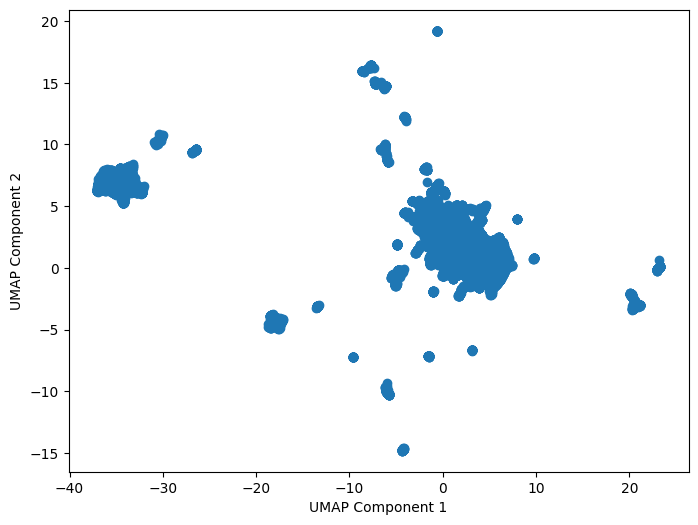

In [98]:
# default
umap_model = umap.UMAP(n_components=2, random_state=42,n_neighbors=50)
umap_components = umap_model.fit_transform(filtered_amenities_for_clustering)

plt.figure(figsize=(8, 6))
plt.scatter(umap_components[:, 0], umap_components[:, 1]) 
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()

In [34]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# Define ranges for eps and min_samples to search
eps_values = np.linspace(0.1, 1.0, 10)  # Range for eps
min_samples_values = range(3, 25)  # Range for min_samples

# Initialize variables to store the best score and parameters
best_score = -1
best_eps = None
best_min_samples = None

# Perform grid search
for eps in eps_values:
    for min_samples in min_samples_values:
        print(f"Running eps/min_sample: {eps}/{min_samples} ")
        # Apply DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(umap_components)
        
        # Only evaluate clustering if there is more than 1 cluster
        if len(set(clusters)) > 1:  # Avoid noise points
            print("more than 2 clusters")
            # Evaluate using silhouette score
            score = silhouette_score(umap_components, clusters)
            if score > best_score:
                print(score)
                best_score = score
                best_eps = eps
                best_min_samples = min_samples

print(f"Best eps: {best_eps}")
print(f"Best min_samples: {best_min_samples}")
print(f"Best silhouette score: {best_score}")

Running eps/min_sample: 0.1/3 
more than 2 clusters
Running eps/min_sample: 0.1/4 
more than 2 clusters
Running eps/min_sample: 0.1/5 
more than 2 clusters
Running eps/min_sample: 0.1/6 
more than 2 clusters
Running eps/min_sample: 0.1/7 
more than 2 clusters
Running eps/min_sample: 0.1/8 
more than 2 clusters
Running eps/min_sample: 0.1/9 
more than 2 clusters
Running eps/min_sample: 0.1/10 
more than 2 clusters
Running eps/min_sample: 0.1/11 
more than 2 clusters
Running eps/min_sample: 0.1/12 
more than 2 clusters
Running eps/min_sample: 0.1/13 
more than 2 clusters
Running eps/min_sample: 0.1/14 
more than 2 clusters
Running eps/min_sample: 0.1/15 
more than 2 clusters
Running eps/min_sample: 0.1/16 
more than 2 clusters
Running eps/min_sample: 0.1/17 
more than 2 clusters
Running eps/min_sample: 0.1/18 
more than 2 clusters
Running eps/min_sample: 0.1/19 
more than 2 clusters
Running eps/min_sample: 0.1/20 
more than 2 clusters
Running eps/min_sample: 0.1/21 
more than 2 clusters


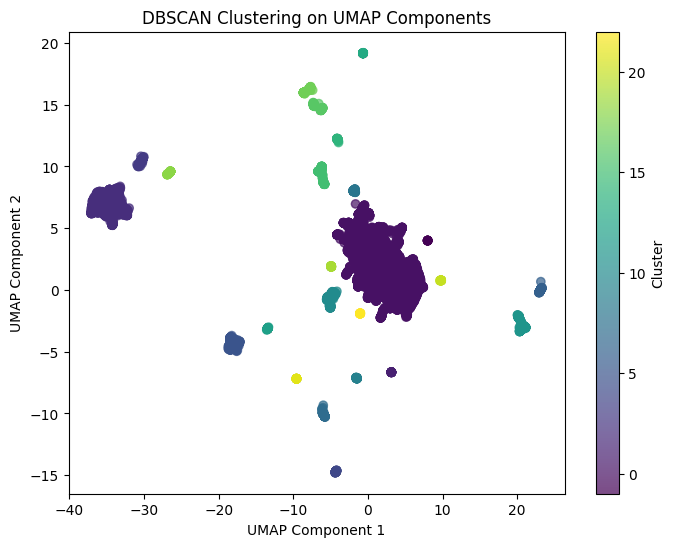

NameError: name 'silhouette_score' is not defined

In [99]:
from sklearn.cluster import DBSCAN


# Apply UMAP
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=50)
umap_components = umap_model.fit_transform(filtered_amenities_for_clustering)

# Create a DataFrame with the UMAP components
umap_df = pd.DataFrame(umap_components, columns=['UMAP Component 1', 'UMAP Component 2'], index=filtered_amenities_for_clustering.index)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=19)
dbscan_clusters = dbscan.fit_predict(umap_components)

# Add DBSCAN cluster column to the DataFrame
umap_df['Cluster'] = dbscan_clusters

# Plot the UMAP components with DBSCAN clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(umap_components[:, 0], umap_components[:, 1], c=dbscan_clusters, cmap='viridis', alpha=0.7)

# Add color bar and labels
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("DBSCAN Clustering on UMAP Components")
plt.colorbar(scatter, label='Cluster')
plt.show()

# Calculate silhouette score
score = silhouette_score(umap_components, dbscan_clusters)
print(f"Silhouette Score: {score}")

# Display the UMAP DataFrame
print(umap_df.head())



In [100]:
filtered_amenities_for_clustering['Cluster'] = dbscan_clusters
print(filtered_amenities_for_clustering.head())

      bathtub  laundromat nearby  clothing storage  elevator  window ac unit  ...  tv  toaster  body soap  exterior security cameras on property  Cluster
id                                                                            ...                                                                        
2595        1                  0                 0         0               0  ...   1        0          0                                      0        0
6848        0                  0                 0         0               0  ...   1        0          0                                      0        0
6990        0                  0                 0         0               0  ...   1        0          0                                      0        0
7097        0                  0                 0         0               0  ...   0        1          0                                      0        0
7801        1                  0                 0         0               1

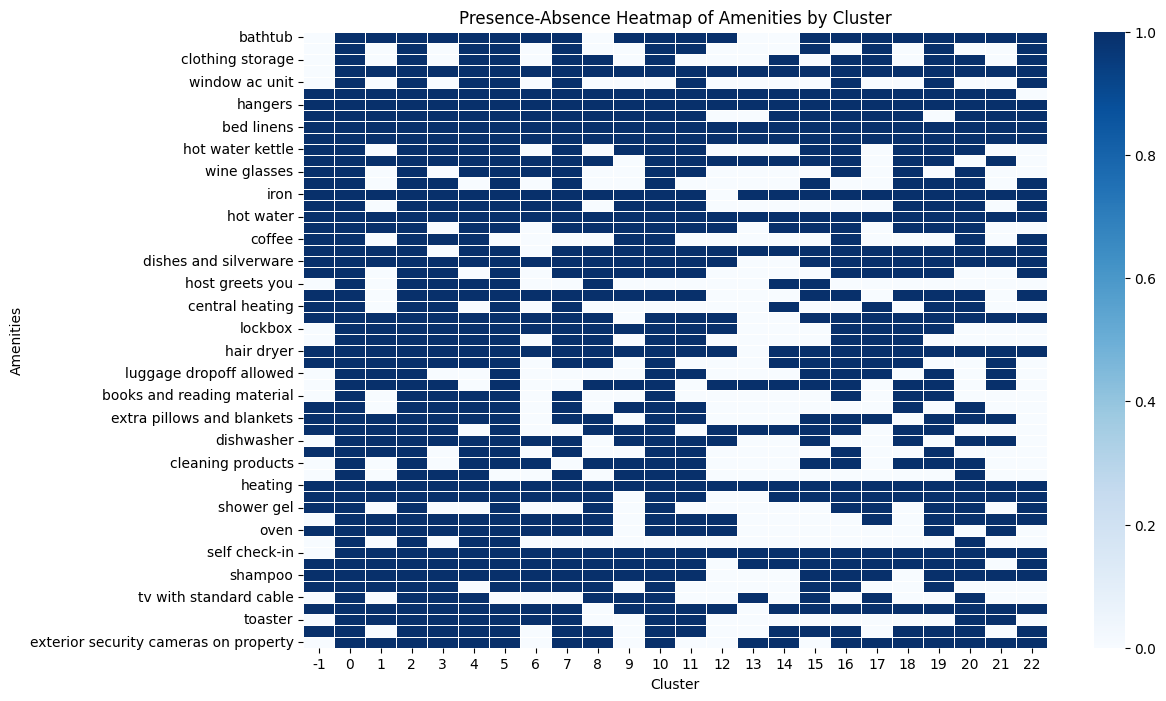

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming `filtered_amenities_for_clustering` has the 'Cluster' column added

# Create a presence-absence matrix for amenities
# 1 if the amenity is present, 0 if absent
amenities_presence_absence = filtered_amenities_for_clustering.drop(columns=['Cluster']).apply(lambda x: x > 0, axis=0).astype(int)

# Add the 'Cluster' column back
amenities_presence_absence['Cluster'] = filtered_amenities_for_clustering['Cluster']

# Create a pivot table with clusters as rows and amenities as columns
pivot_table = amenities_presence_absence.groupby('Cluster').agg(lambda x: x.max()).T

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='Blues', cbar=True, annot=False, fmt="d", linewidths=0.5)
plt.title('Presence-Absence Heatmap of Amenities by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Amenities')
plt.show()


          bathtub  laundromat nearby  clothing storage  elevator  ...        tv   toaster  body soap  exterior security cameras on property
Cluster                                                           ...                                                                      
-1       0.000000           0.000000          0.000000  0.000000  ...  1.000000  0.000000   0.909091                               0.000000
 0       0.467400           0.388774          0.205456  0.189245  ...  0.509462  0.406913   0.349425                               0.348283
 1       0.967742           0.000000          0.000000  1.000000  ...  1.000000  0.967742   0.000000                               0.064516
 2       0.031154           0.017990          0.007021  0.021939  ...  0.723124  0.005265   0.013164                               0.302764
 3       0.007874           0.000000          0.000000  0.003937  ...  0.942913  0.001969   0.001969                               0.066929
 4       0.006623   

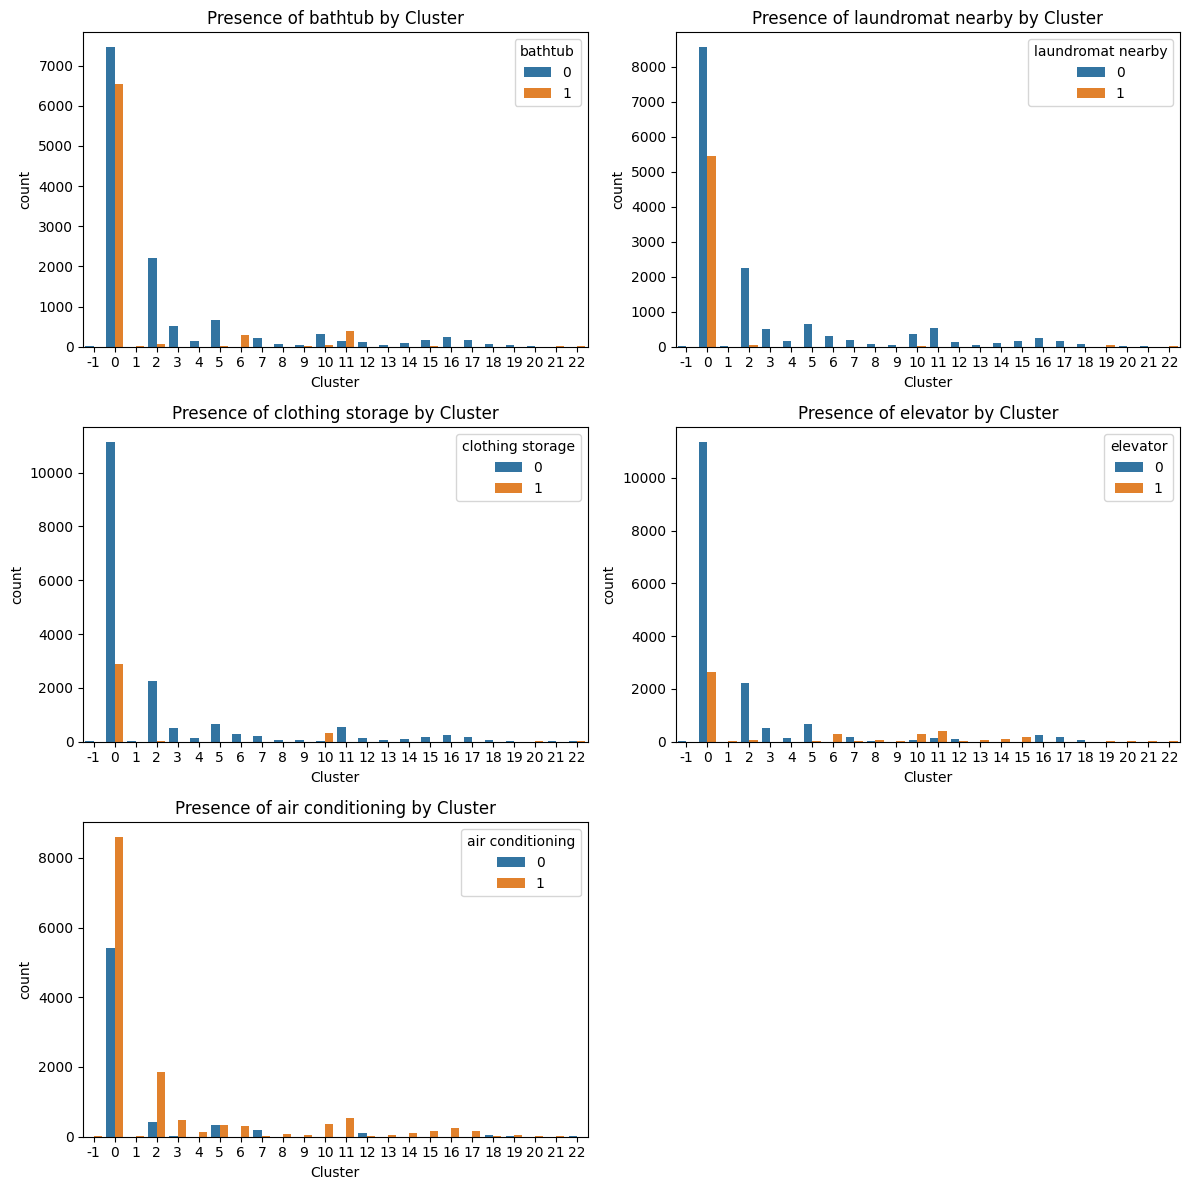

In [107]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Create a presence-absence matrix (1 for present, 0 for absent)
amenities_presence_absence = filtered_amenities_for_clustering.drop(columns=['Cluster']).apply(lambda x: x > 0, axis=0).astype(int)

# Add cluster labels to the DataFrame
amenities_presence_absence['Cluster'] = filtered_amenities_for_clustering['Cluster']

# Calculate the mean presence of each amenity for each cluster
cluster_amenity_means = amenities_presence_absence.groupby('Cluster').mean()

# Show the means (percentage of listings that have each amenity per cluster)
print(cluster_amenity_means)

# Perform Chi-Squared tests for each amenity
chi2_results = {}
for amenity in amenities_presence_absence.columns[:-1]:  # Exclude the 'Cluster' column
    contingency_table = pd.crosstab(amenities_presence_absence[amenity], amenities_presence_absence['Cluster'])
    chi2_stat, p_val, dof, ex = chi2_contingency(contingency_table)
    chi2_results[amenity] = p_val

# Show amenities with significant differences (p < 0.05)
significant_amenities = {amenity: p_val for amenity, p_val in chi2_results.items() if p_val < 0.05}
print("Significant Amenities that define clusters:")
print(significant_amenities)

# Select top amenities to visualize (top 5 amenities with the lowest p-value)
amenities_to_visualize = sorted(significant_amenities, key=significant_amenities.get)[:5]  # Select top 5 amenities

# Plotting a bar plot for the presence of these amenities by cluster
plt.figure(figsize=(12, 12))
for i, amenity in enumerate(amenities_to_visualize):
    plt.subplot(3, 2, i + 1)  # Adjust the number of rows and columns as needed
    sns.countplot(data=amenities_presence_absence, x='Cluster', hue=amenity)
    plt.title(f'Presence of {amenity} by Cluster')

plt.tight_layout()
plt.show()


In [109]:
amenities_and_booking_ratio =  pd.merge(amenities_presence_absence, booking_ratios, left_index=True, right_on='listing_id', how='left')
amenities_and_booking_ratio = pd.merge(amenities_and_booking_ratio,listings,left_index=True,right_on='id')


amenities_and_booking_ratio['price'] = amenities_and_booking_ratio['price'].replace({'\\$': '', ',': ''}, regex=True)
amenities_and_booking_ratio['price'] = pd.to_numeric(amenities_and_booking_ratio['price'], errors='coerce')

amenities_and_booking_ratio['price_category'] = pd.cut(amenities_and_booking_ratio['price'], bins=[0, 100, 500, 1000, 5000], 
                                       labels=['Low', 'Medium', 'High', 'Luxury'])

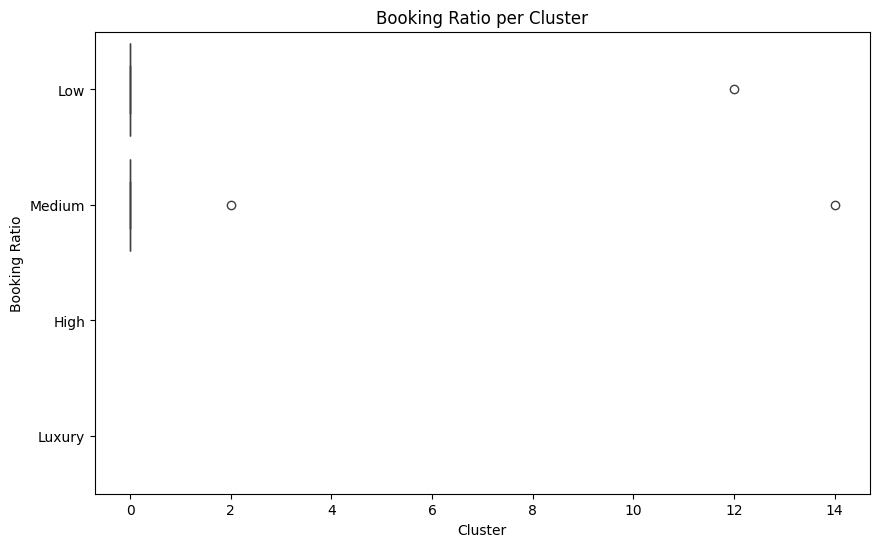

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your merged DataFrame contains both 'Cluster' and 'booking_ratio' columns
plt.figure(figsize=(10, 6))

# Create a boxplot of booking ratio per cluster
sns.boxplot(x='Cluster', y='price_category', data=amenities_and_booking_ratio)

# Customize the plot
plt.title('Booking Ratio per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Booking Ratio')
plt.show()

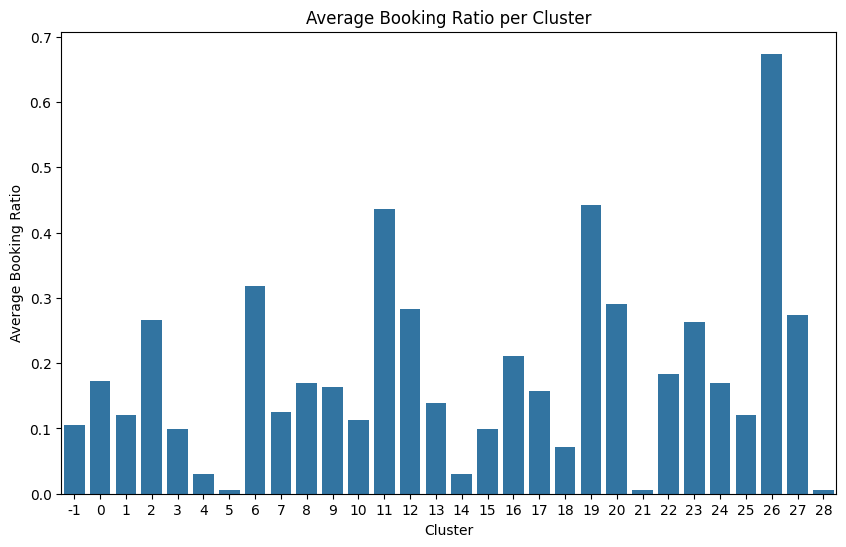

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your merged DataFrame contains both 'Cluster' and 'booking_ratio' columns

# Calculate the average booking ratio per cluster
average_booking_ratio = amenities_and_booking_ratio.groupby('Cluster')['booking_ratio'].median().reset_index()

# Plot the average booking ratio per cluster
plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster', y='booking_ratio', data=average_booking_ratio)

# Customize the plot
plt.title('Average Booking Ratio per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Booking Ratio')
plt.show()


In [110]:
umap_and_booking_ratio =  pd.merge(umap_df, booking_ratios, left_index=True, right_on='listing_id', how='left')
umap_and_booking_ratio

,UMAP Component 1,UMAP Component 2,Cluster,Unnamed: 0,listing_id,total_days,unavailable_days,available_days,booking_ratio
0,2.038692,2.685509,0,0,2595,365,0,365,0.000000
1,1.631108,3.607651,0,1,6848,365,180,185,0.493151
3,-0.530340,3.643031,0,3,6990,365,81,284,0.221918
5,5.678100,1.096516,0,5,7097,365,150,215,0.410959
6,6.532597,0.031996,0,6,7801,365,106,259,0.290411
...,...,...,...,...,...,...,...,...,...
37540,-33.689285,6.245312,2,37540,1280784833142464571,365,117,248,0.320548
37541,-17.723412,-4.618753,5,37541,1281096465598617765,365,29,336,0.079452
37543,4.067332,0.461949,0,37543,1281263542832791722,365,241,124,0.660274
37544,-33.387154,7.983059,2,37544,1281431427554747842,365,1,364,0.002740


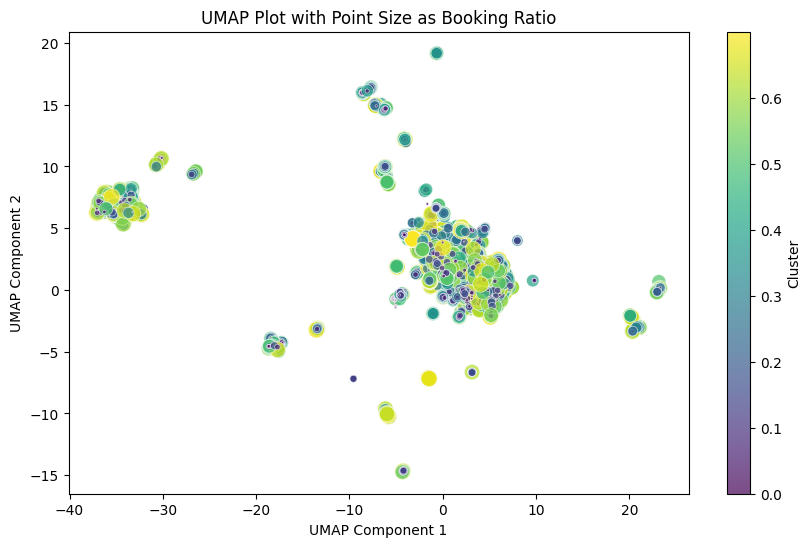

In [111]:
import matplotlib.pyplot as plt

# Plot the UMAP components with point size proportional to the booking ratio
plt.figure(figsize=(10, 6))

# Use 'booking_ratio' to scale the point size. We scale it to make the points visually distinct
# You can adjust the scaling factor (e.g., *200) to get the desired point size range
plt.scatter(umap_and_booking_ratio['UMAP Component 1'], umap_and_booking_ratio['UMAP Component 2'], 
            c=umap_and_booking_ratio['booking_ratio'], cmap='viridis', alpha=0.7, 
            s=umap_and_booking_ratio['booking_ratio']*200,  # Adjust the multiplier to control size
            edgecolors='w', linewidth=0.5)

# Add color bar and labels
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("UMAP Plot with Point Size as Booking Ratio")
plt.colorbar(label='Cluster')

plt.show()


C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


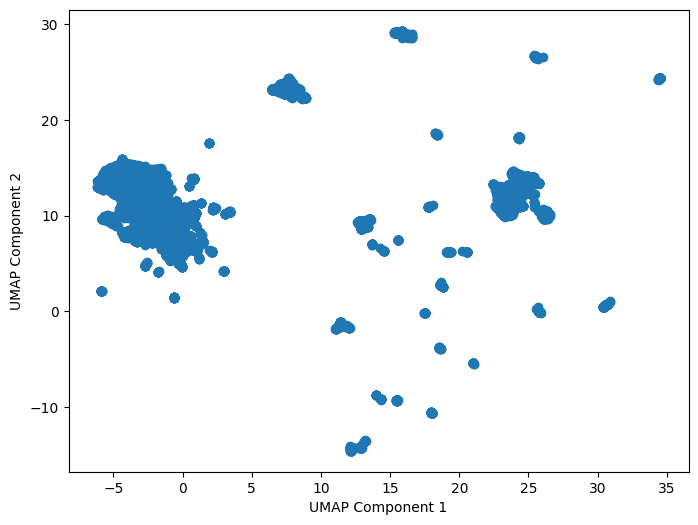

In [112]:
umap_model = umap.UMAP(n_components=2, random_state=42, metric='cosine',n_neighbors=50)
umap_components = umap_model.fit_transform(filtered_amenities_for_clustering)

plt.figure(figsize=(8, 6))
plt.scatter(umap_components[:, 0], umap_components[:, 1]) 
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


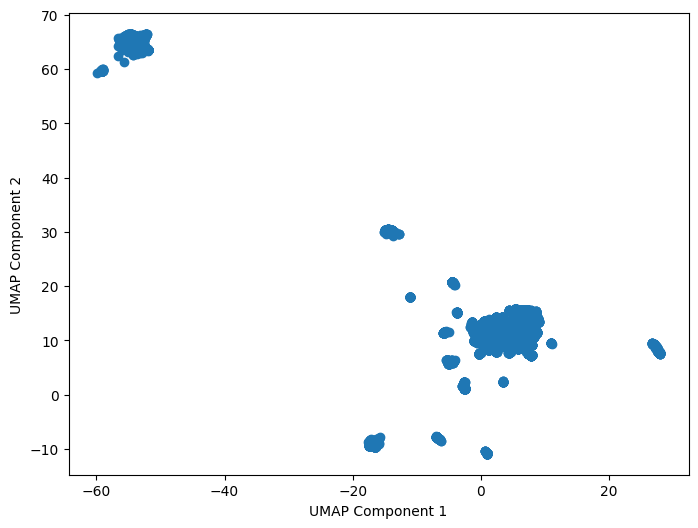

## cluster umap 

         UMAP1     UMAP2  Cluster_DBSCAN
2595  8.038304 -2.870914              -1
6848  3.941786 -3.714545              -1
6990  3.915103 -4.566453              -1
7097  5.018673 -4.059225              -1
7801  4.428832 -3.767151              -1


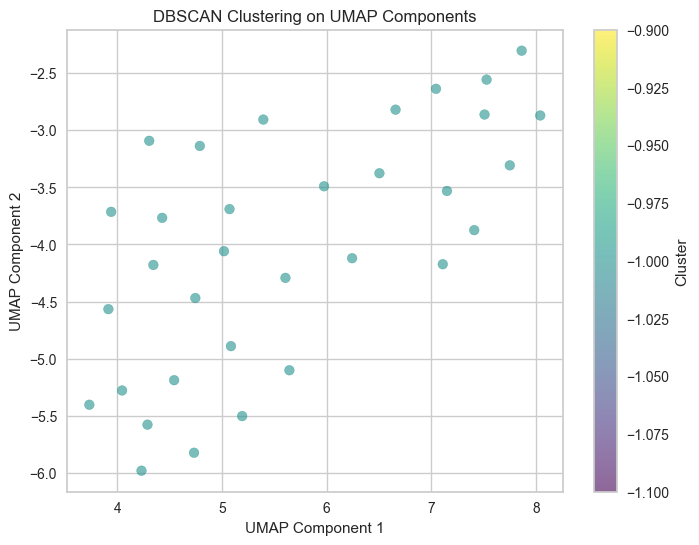

In [85]:
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_components = umap_model.fit_transform(filtered_amenities_for_clustering)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust eps and min_samples based on your data
umap_clusters = dbscan.fit_predict(umap_components)

# Create a DataFrame with UMAP components, cluster labels, and the original index
umap_df = pd.DataFrame(umap_components, columns=['UMAP1', 'UMAP2'], index=filtered_amenities_for_clustering.index)
umap_df['Cluster_DBSCAN'] = umap_clusters

# Display the DataFrame with UMAP and DBSCAN results
print(umap_df.head())

# Visualize the DBSCAN clustering result
plt.figure(figsize=(8, 6))
plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], c=umap_df['Cluster_DBSCAN'], cmap='viridis', alpha=0.6)
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("DBSCAN Clustering on UMAP Components")
plt.colorbar(label='Cluster')
plt.show()

In [81]:
# add booking ratio to cluster df
umap_df = pd.DataFrame(umap_components, columns=['UMAP1', 'UMAP2'])
umap_df['Cluster'] = umap_clusters_dbscan

umap_df

,UMAP1,UMAP2,Cluster
0,0.860419,-0.368973,0
1,2.585583,-0.352466,0
2,-8.662599,-9.524661,1
3,-0.873748,-10.619809,2
4,-8.635820,-8.885226,1
...,...,...,...
37543,-4.778137,-14.719233,11
37544,3.798227,-10.225094,2
37545,-1.793359,1.907142,0
37546,3.543606,-10.867783,2


## merge all of the data

In [38]:
merged_data = pd.merge(listings,booking_ratios,left_on='id', right_on='listing_id')
#merged_data = pd.merge(merged_data,neighborhood_facilities,left_on='neighbourhood_cleansed',right_on='neighborhood')
#merged_data = pd.merge(merged_data,amenities_filtered,left_on='id',right_on='id')

merged_data.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,Unnamed: 0,listing_id,total_days,unavailable_days,available_days,booking_ratio
0,2595,https://www.airbnb.com/rooms/2595,20241104040953,2024-11-04,city scrape,Skylit Midtown Castle Sanctuary,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/miso/Hosting-...,2845,https://www.airbnb.com/users/show/2845,Jennifer,2008-09-09,"Woodstock, NY",A New Yorker since 2000! My passion is creatin...,within a day,90%,21%,f,https://a0.muscache.com/im/pictures/user/50fc5...,https://a0.muscache.com/im/pictures/user/50fc5...,Midtown,7.0,9.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Midtown,Manhattan,40.75356,-73.98559,Entire rental unit,Entire home/apt,1,1.0,1 bath,0.0,1.0,"[""Fire extinguisher"", ""Smoke alarm"", ""Stove"", ...",$240.00,30,1125,30.0,30.0,1125.0,1125.0,30.0,1125.0,NaN,t,30,60,90,365,2024-11-04,49,0,0,2009-11-21,2022-06-21,4.68,4.73,4.63,4.77,4.80,4.81,4.40,NaN,f,3,3,0,0,0.27,0,2595,365,0,365,0.000000
1,6848,https://www.airbnb.com/rooms/6848,20241104040953,2024-11-04,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,https://www.airbnb.com/users/show/15991,Allen & Irina,2009-05-06,"New York, NY",We love to travel. When we travel we like to s...,within a few hours,100%,100%,t,https://a0.muscache.com/im/users/15991/profile...,https://a0.muscache.com/im/users/15991/profile...,Williamsburg,1.0,1.0,"['email', 'phone']",t,t,NaN,Williamsburg,Brooklyn,40.70935,-73.95342,Entire rental unit,Entire home/apt,3,1.0,1 bath,2.0,1.0,"[""Fire extinguisher"", ""Smoke alarm"", ""Stove"", ...",$83.00,30,120,30.0,30.0,120.0,120.0,30.0,120.0,NaN,t,0,15,15,185,2024-11-04,195,4,1,2009-05-25,2024-10-05,4.58,4.59,4.85,4.85,4.80,4.69,4.58,NaN,f,1,1,0,0,1.04,1,6848,365,180,185,0.493151
2,6872,https://www.airbnb.com/rooms/6872,20241104040953,2024-11-04,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,This sweet Harlem sanctuary is a 10-20 minute ...,https://a0.muscache.com/pictures/miso/Hosting-...,16104,https://www.airbnb.com/users/show/16104,Kae,2009-05-07,"New York, NY",A former life in fashion and wellness has left...,a few days or more,30%,33%,f,https://a0.muscache.com/im/pictures/user/d865a...,https://a0.muscache.com/im/pictures/user/d865a...,East Harlem,2.0,2.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,East Harlem,Manhattan,40.80107,-73.94255,Private room in condo,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Heating"", ""Washer"", ""Fire extinguisher"", ""Sm...",$65

## clean merged data
remove unnecessary columns that wont affect popularity and maybe some like number of reviews that could have data leakage. Also drop rows with missing data.
Most rows with missing data are not active listings and add large amounts of noise to thhe data and have inaccurate booking ratio representation

In [39]:
merged_data = merged_data.drop(columns=['listing_url','scrape_id','last_scraped','source','name','description','neighborhood_overview','picture_url','host_id',
    'host_url','host_name','host_since','host_location','host_about','host_thumbnail_url','host_picture_url','host_neighbourhood','host_listings_count','host_total_listings_count',
    'host_verifications','neighbourhood','neighbourhood_group_cleansed','latitude','longitude','amenities','minimum_minimum_nights','maximum_maximum_nights','minimum_maximum_nights',
    'maximum_maximum_nights','minimum_nights_avg_ntm','maximum_nights_avg_ntm','calendar_updated','has_availability','availability_30','availability_60','availability_90',
    'availability_365','calendar_last_scraped','number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d','first_review','last_review','calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms','reviews_per_month','review_scores_accuracy'])
merged_data.head()

merged_data = merged_data.drop(columns=['total_days','unavailable_days','available_days'])

merged_data = merged_data.dropna() 
merged_data = merged_data.drop(columns=['listing_id','id'])

#remove any lingering listings withh more than 70% booking ratio (invalid listings)
merged_data = merged_data[(merged_data['booking_ratio'] <= 0.70)]

merged_data['price'] = merged_data['price'].replace({'\\$': '', ',': ''}, regex=True)
merged_data['price'] = pd.to_numeric(merged_data['price'], errors='coerce')

merged_data['host_response_rate'] = merged_data['host_response_rate'].replace({'\\%': '', ',': ''}, regex=True)
merged_data['host_response_rate'] = pd.to_numeric(merged_data['host_response_rate'], errors='coerce')

merged_data['host_acceptance_rate'] = merged_data['host_acceptance_rate'].replace({'\\%': '', ',': ''}, regex=True)
merged_data['host_acceptance_rate'] = pd.to_numeric(merged_data['host_acceptance_rate'], errors='coerce')

low_threshold = 0.30
high_threshold = .5

merged_data.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,maximum_minimum_nights,review_scores_rating,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,Unnamed: 0,booking_ratio
5,within an hour,100,100,t,t,t,Fort Greene,Private room in guest suite,Private room,2,1.0,1 private bath,1.0,2.0,205.0,2,1125,2.0,4.89,4.89,4.96,4.93,4.95,4.82,OSE-STRREG-0000008,t,5,0.410959
18,within an hour,100,100,t,t,t,East Village,Private room in condo,Private room,1,1.0,1 shared bath,1.0,1.0,170.0,1,40,2.0,4.80,4.77,4.79,4.79,4.73,4.69,OSE-STRREG-0000108,f,18,0.619178
39,within an hour,100,100,t,t,t,Clinton Hill,Private room in condo,Private room,2,1.0,1 shared bath,1.0,1.0,152.0,3,60,3.0,4.95,4.94,4.99,4.98,4.87,4.92,OSE-STRREG-0000041,t,39,0.649315
43,within an hour,100,100,t,t,t,Clinton Hill,Private room in rental unit,Private room,2,1.0,1 private bath,1.0,1.0,127.0,2,365,2.0,4.54,4.46,4.77,4.76,4.75,4.60,OSE-STRREG-0000832,t,43,0.161644
49,within a few hours,100,50,f,t,t,Boerum Hill,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,900.0,3,60,3.0,4.70,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,f,49,0.030137


In [32]:
from pycaret.classification import *

# Now, setup PyCaret with the categorical columns explicitly as a list
exp1 = setup(data=merged_data, 
             target='popularity_level',  # The column you want to predict
             session_id=42,  # For reproducibility
             normalize=True)

ImportError: cannot import name '_print_elapsed_time' from 'sklearn.utils' (C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\__init__.py)

In [86]:
best_models=exp1.compare_models()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,21:41:38
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


Processing:   0%|          | 0/61 [00:00<?, ?it/s]

## encode listings data
encoding the data to be able to cluster and use dimensional reduction techniques

In [89]:
dim_reduc_df = merged_data.copy()
dim_reduc_df = dim_reduc_df.drop(columns=[col for col in dim_reduc_df.columns if 'id' in col.lower()])

numerical_columns = dim_reduc_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = dim_reduc_df.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns)
    ])

dim_reduc_df_encoded = preprocessor.fit_transform(dim_reduc_df)
dim_reduc_df_encoded = pd.DataFrame(dim_reduc_df_encoded, columns=all_columns, index=dim_reduc_df.index)


ValueError: Shape of passed values is (2729, 1), indices imply (2729, 1519)

remove columns that are bad for dimensional reduction like constant columns, low variance columns, and columns with too many unique values

PCA

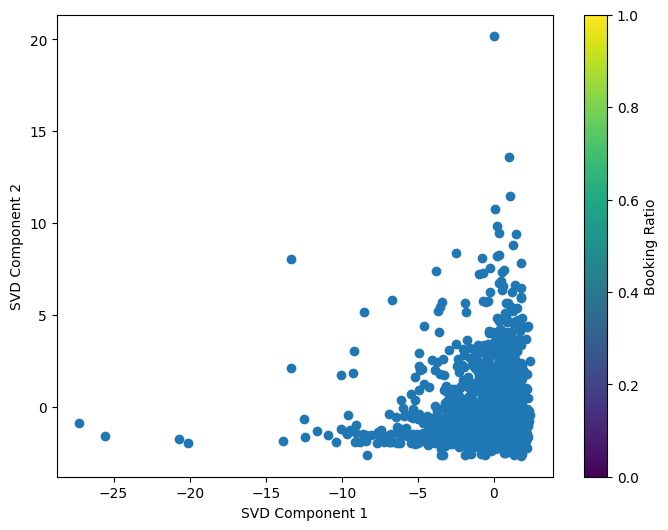

In [41]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Use TruncatedSVD as a replacement for PCA
svd = TruncatedSVD(n_components=2)
svd_components = svd.fit_transform(dim_reduc_df_encoded)

plt.figure(figsize=(8, 6))
plt.scatter(svd_components[:, 0], svd_components[:, 1])
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.colorbar(label='Booking Ratio')
plt.show()

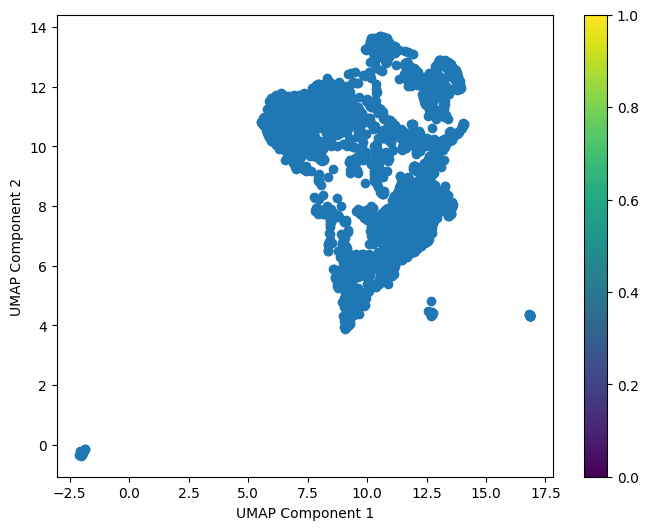

In [69]:
umap_model = umap.UMAP(n_components=2, random_state=42,n_neighbors=30,min_dist=.1)
umap_components = umap_model.fit_transform(dim_reduc_df_encoded)

plt.figure(figsize=(8, 6))
plt.scatter(umap_components[:, 0], umap_components[:, 1]) 
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.colorbar()
plt.show()

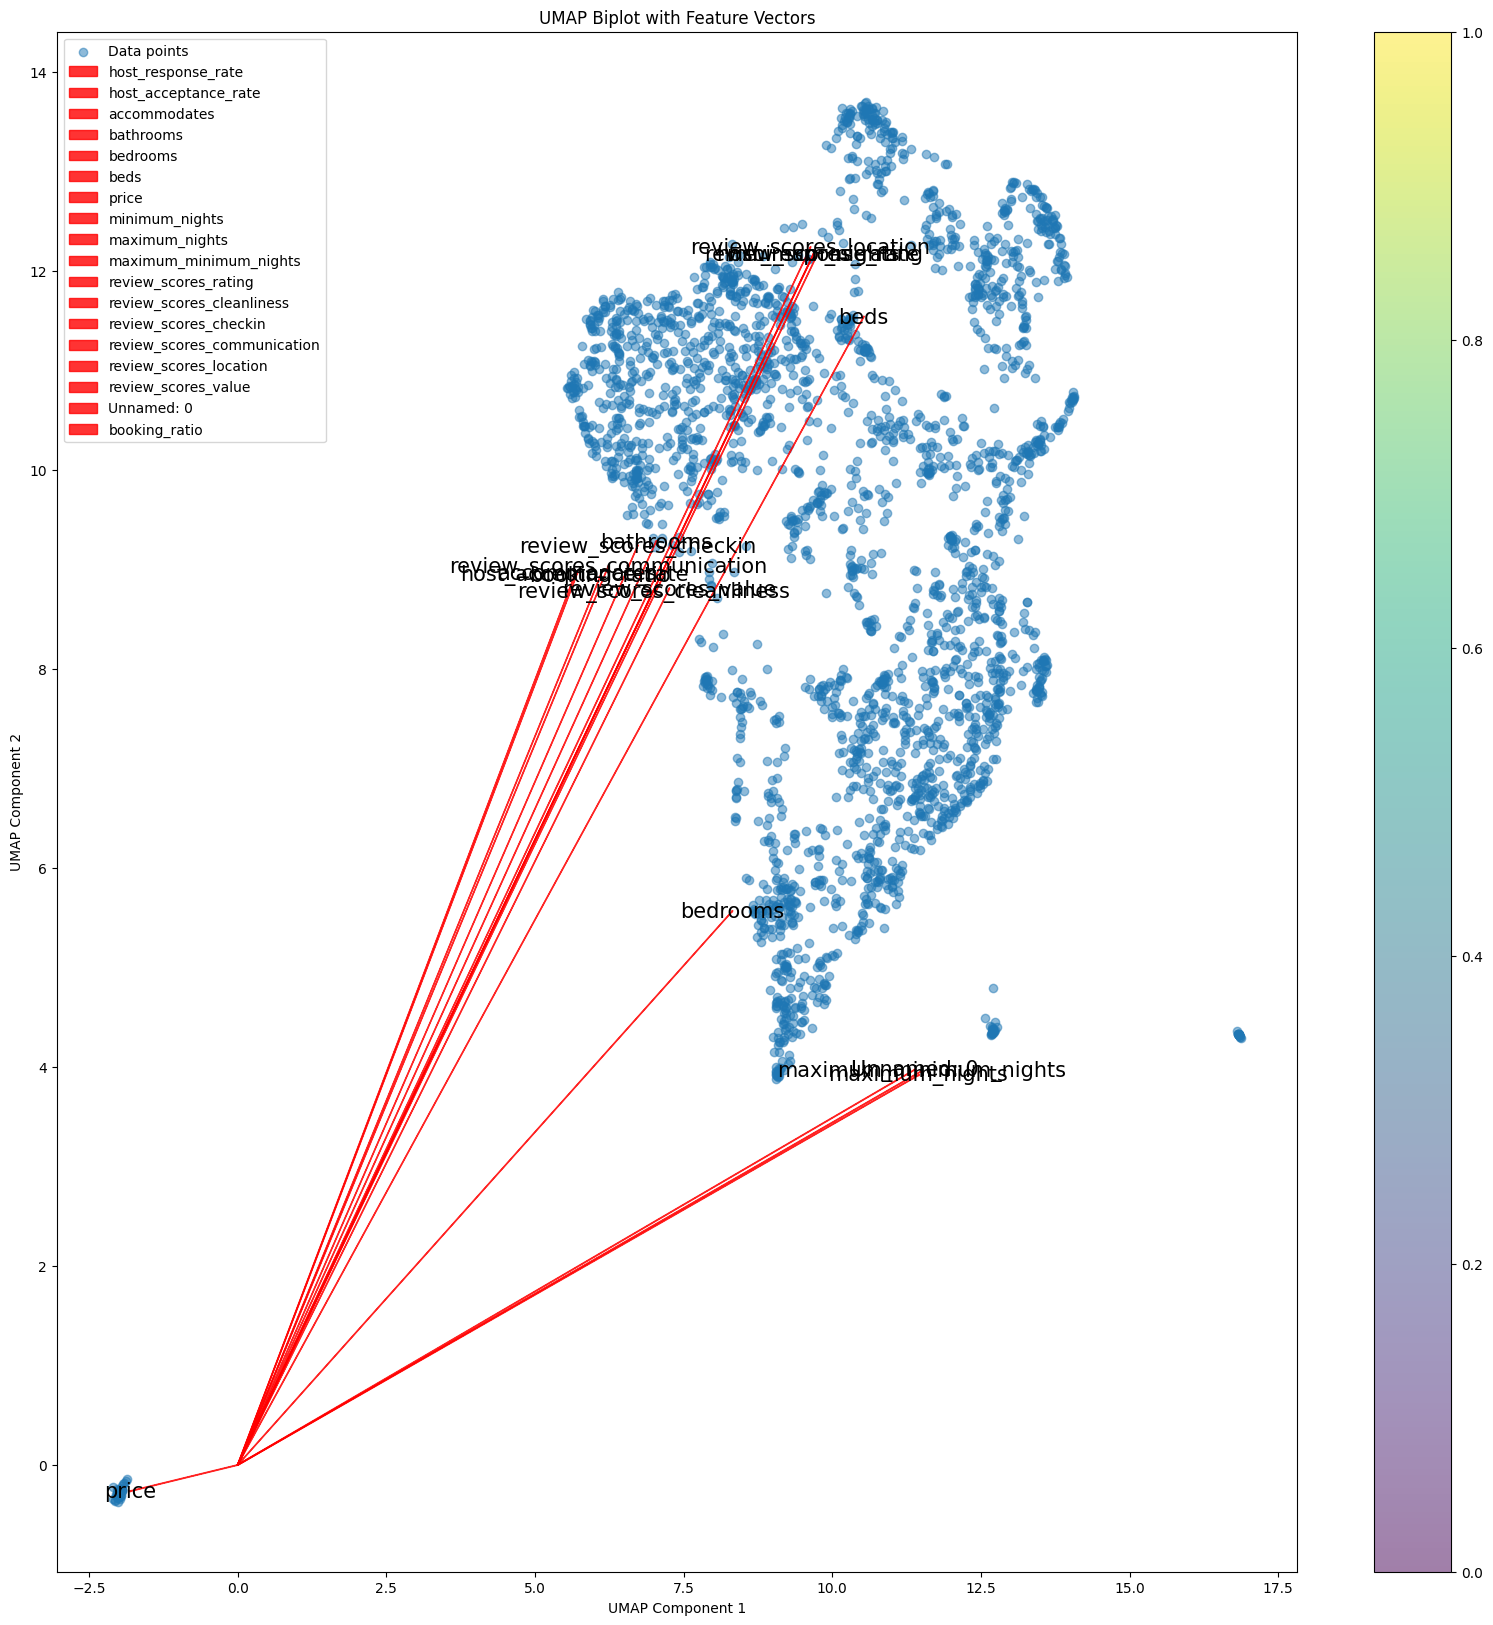

In [70]:
num_features = numerical_columns

umap_df = pd.DataFrame(umap_components, columns=['UMAP Component 1', 'UMAP Component 2'])

plt.figure(figsize=(20, 20))
plt.scatter(umap_df['UMAP Component 1'], umap_df['UMAP Component 2'], label='Data points', alpha=0.5)

arrow_scale = 0.9  # Adjust this to increase arrow length

# Loop through the features to plot arrows
for i, feature in enumerate(num_features):
    plt.arrow(0, 0, umap_model.embedding_[:, 0][i] * arrow_scale, 
              umap_model.embedding_[:, 1][i] * arrow_scale, 
              color='red', alpha=0.8, width=0.005, label=feature)

    # Add labels to each feature arrow
    plt.text(umap_model.embedding_[:, 0][i] * arrow_scale, 
             umap_model.embedding_[:, 1][i] * arrow_scale, 
             feature, color='black', fontsize=15, ha='center', va='center')

plt.title("UMAP Biplot with Feature Vectors")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.colorbar()
plt.legend(loc="best")
plt.show()

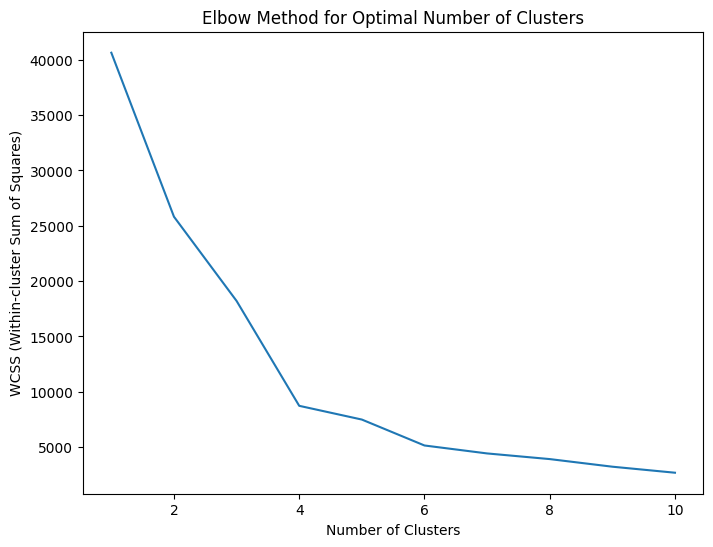

In [71]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score

# Calculate the Elbow Method for KMeans clustering
wcss = []  # Within-cluster sum of squares
for i in range(1, 11):  # Testing for 1 to 10 clusters
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(umap_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-cluster Sum of Squares)')
plt.show()


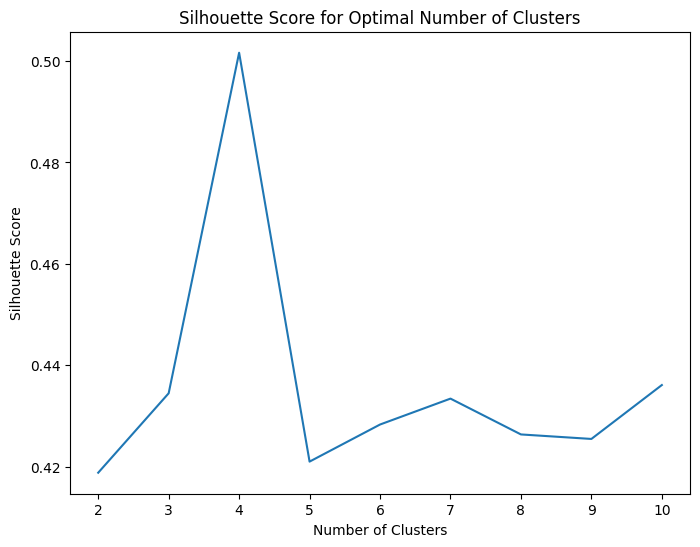

In [72]:
# Silhouette score for different numbers of clusters
sil_scores = []
for i in range(2, 11):  # Testing for 2 to 10 clusters
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(umap_df)
    sil_scores.append(silhouette_score(umap_df, kmeans.labels_))

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), sil_scores)
plt.title('Silhouette Score for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()


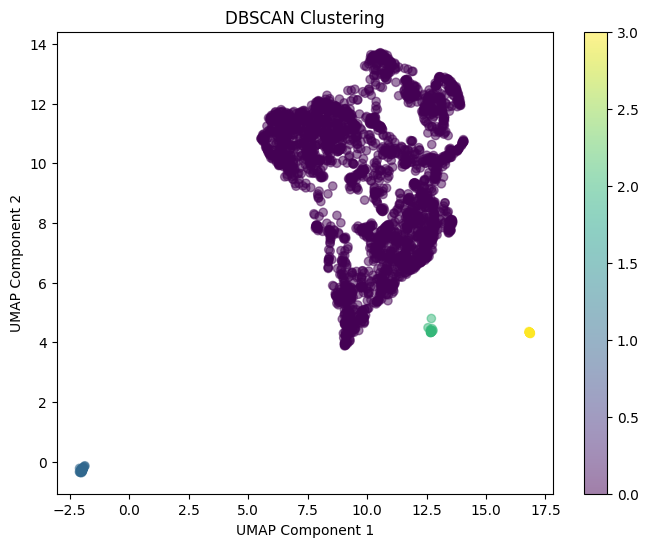

In [73]:
from sklearn.cluster import DBSCAN

# Use DBSCAN to cluster the data
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust eps and min_samples as necessary
dbscan_labels = dbscan.fit_predict(umap_df)

# Plot the DBSCAN clusters
plt.figure(figsize=(8, 6))
plt.scatter(umap_df['UMAP Component 1'], umap_df['UMAP Component 2'], c=dbscan_labels, cmap='viridis', alpha=0.5)
plt.title('DBSCAN Clustering')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.colorbar()
plt.show()


In [90]:
dim_reduc_df_encoded['cluster'] = dbscan_labels

# Calculate the mean of original features per cluster
cluster_means = dim_reduc_df_encoded.groupby('cluster').mean()

print(cluster_means)

IndexError: Index dimension must be 1 or 2

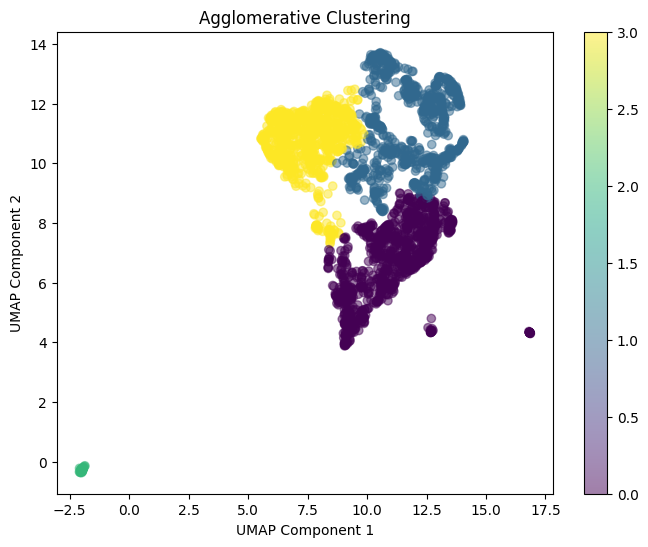

In [80]:
from sklearn.cluster import AgglomerativeClustering

# Fit Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=4)  # Set the number of clusters (could also try different values)
agglo_labels = agglo.fit_predict(umap_df)

# Plot the Agglomerative Clusters
plt.figure(figsize=(8, 6))
plt.scatter(umap_df['UMAP Component 1'], umap_df['UMAP Component 2'], c=agglo_labels, cmap='viridis', alpha=0.5)
plt.title('Agglomerative Clustering')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.colorbar()
plt.show()


In [81]:
dim_reduc_df_encoded['cluster'] = agglo_labels

# Calculate the mean of original features per cluster
cluster_means = dim_reduc_df_encoded.groupby('cluster').mean()

print(cluster_means)

IndexError: Index dimension must be 1 or 2

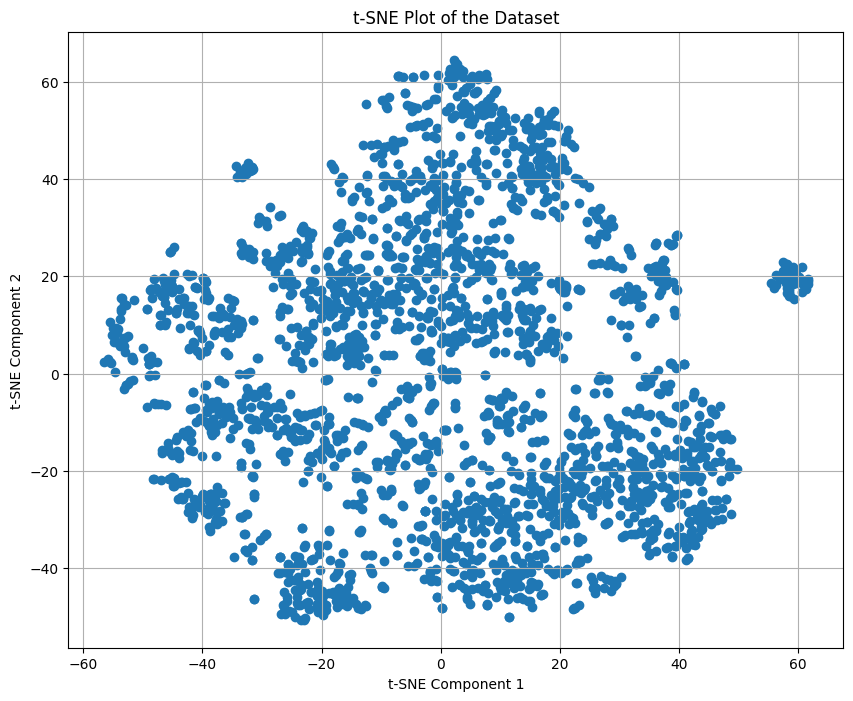

In [79]:
from sklearn.manifold import TSNE
dim_reduc_df_encoded_dense = dim_reduc_df_encoded.toarray() if hasattr(dim_reduc_df_encoded, 'toarray') else dim_reduc_df_encoded

tsne = TSNE(n_components=2, random_state=42)
tsne_components = tsne.fit_transform(dim_reduc_df_encoded_dense)
plt.figure(figsize=(10, 8))
plt.scatter(tsne_components[:, 0], tsne_components[:, 1], )


plt.title("t-SNE Plot of the Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()

In [84]:


# Assuming tsne_components is your t-SNE output (numpy array)
# Create the DataFrame for t-SNE components with 'tSNE_1' and 'tSNE_2' columns
tsne_df = pd.DataFrame(tsne_components, columns=['tSNE_1', 'tSNE_2'])

merged_df = pd.merge(tsne_df, merged_data, left_index=True, right_index=True)

# Now 'merged_df' contains the t-SNE components and the additional data
print(merged_df)

         tSNE_1     tSNE_2  host_response_time  host_response_rate  host_acceptance_rate host_is_superhost  ... review_scores_location review_scores_value             license instant_bookable Unnamed: 0  booking_ratio
5    -41.425205   6.310733      within an hour                 100                   100                 t  ...                   4.95                4.82  OSE-STRREG-0000008                t          5       0.410959
18    20.885921  18.173004      within an hour                 100                   100                 t  ...                   4.73                4.69  OSE-STRREG-0000108                f         18       0.619178
39    16.327160  19.965418      within an hour                 100                   100                 t  ...                   4.87                4.92  OSE-STRREG-0000041                t         39       0.649315
43    18.476583  18.675905      within an hour                 100                   100                 t  ...                 

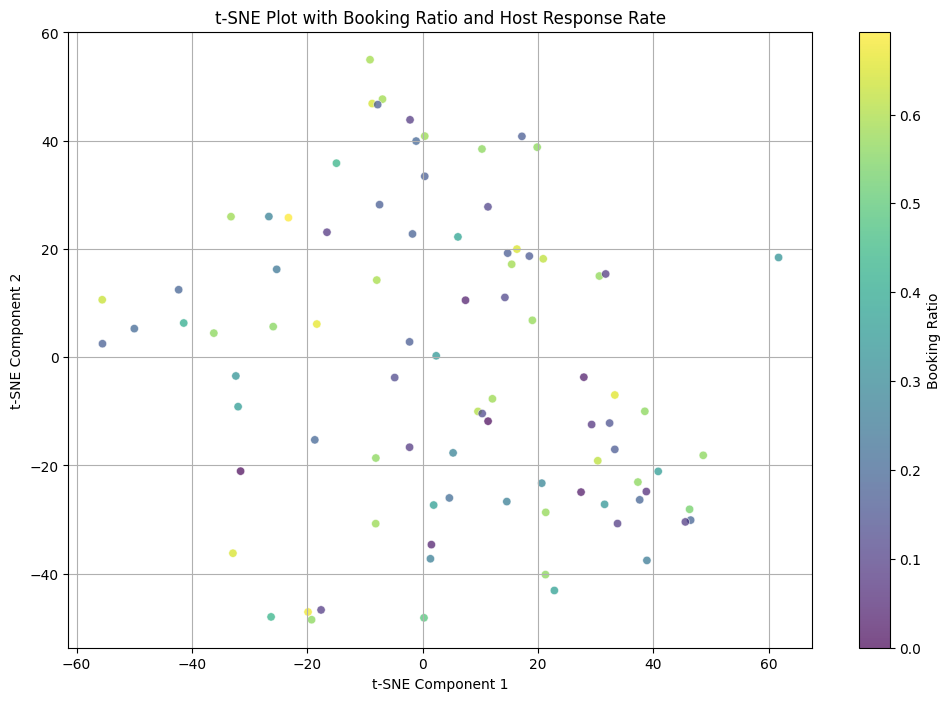

In [87]:
import matplotlib.pyplot as plt

# Assuming `merged_df` contains your merged data with columns ['tSNE_1', 'tSNE_2', 'booking_ratio', ...]

plt.figure(figsize=(12, 8))

# Scatter plot with color based on booking_ratio and size based on host_response_rate (you can adjust which feature to use)
plt.scatter(merged_df['tSNE_1'], merged_df['tSNE_2'], 
            c=merged_df['booking_ratio'], cmap='viridis', alpha=0.7, 
            edgecolors='w', linewidth=0.5)

# Add color bar and labels
plt.colorbar(label='Booking Ratio')  # Color bar for booking ratio
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Plot with Booking Ratio and Host Response Rate')

plt.grid(True)
plt.show()

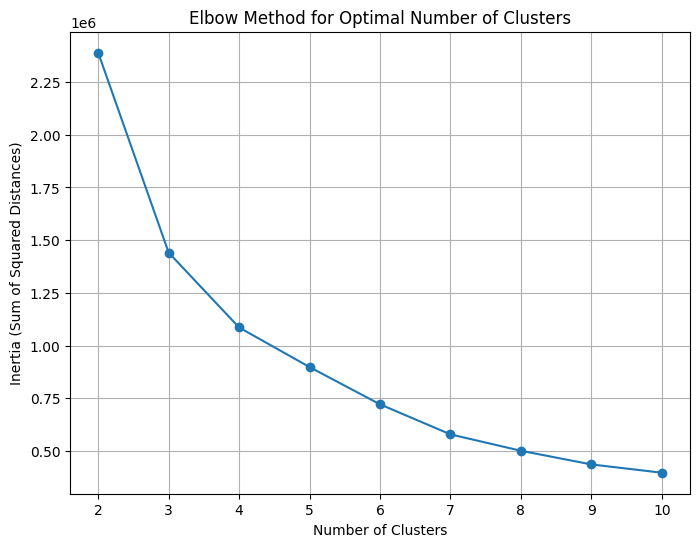

In [82]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Compute the inertia for a range of cluster numbers
inertia = []
range_n_clusters = range(2, 11)  # Check from 2 to 10 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(tsne_components)
    inertia.append(kmeans.inertia_)

# Plot the inertia vs. number of clusters
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.grid(True)
plt.show()


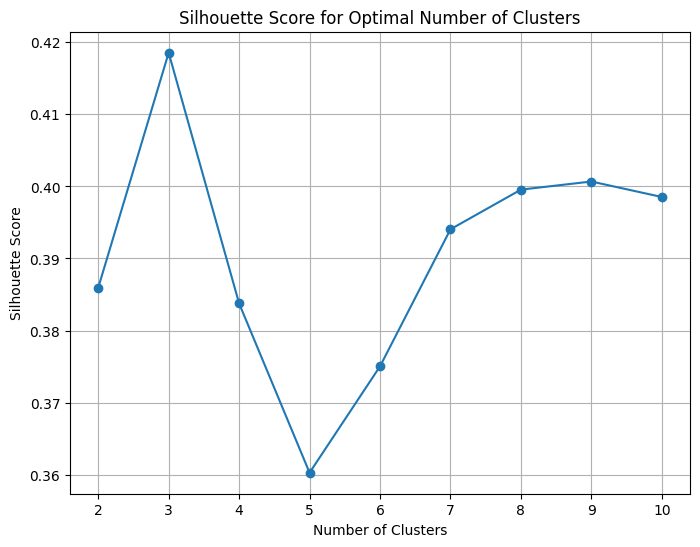

The optimal number of clusters is: 3


In [83]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for a range of cluster numbers
silhouette_scores = []
range_n_clusters = range(2, 11)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(tsne_components)
    score = silhouette_score(tsne_components, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title("Silhouette Score for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Print the number of clusters with the highest silhouette score
optimal_clusters = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
print(f"The optimal number of clusters is: {optimal_clusters}")
